In [8]:
emb1.shape

torch.Size([1, 4, 768])

In [93]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load model and tokenizer
model = GPT2LMHeadModel.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# Two different prompts of same length
prompt1 = "Pink Floyd, Black Sabbath, AC/, "
prompt2 = "Как твои"

# Tokenize inputs
tokens1 = tokenizer(prompt1, return_tensors="pt")
tokens2 = tokenizer(prompt2, return_tensors="pt")

print(tokens1)
print(tokens2)
# Get embeddings from first layer
def get_first_layer_embedding(input_ids):
    # Get the word embeddings layer
    embedding_layer = model.transformer.wte
    # Get embeddings for input
    embeddings = embedding_layer(input_ids)
    return embeddings

# Get embeddings for both prompts
emb1 = get_first_layer_embedding(tokens1.input_ids)
emb2 = get_first_layer_embedding(tokens2.input_ids)

# Average the embeddings
avg_emb = (emb1 + emb2) / 2

# Run model with original prompts and averaged embedding
with torch.no_grad():
    # Original outputs
    out1 = model(**tokens1)
    out2 = model(**tokens2)
    
    # Run with averaged embedding by replacing first layer
    # Store original embeddings
    orig_forward = model.transformer.wte.forward
    
    # Override embedding forward pass
    def new_forward(input_ids):
        return avg_emb
    
    model.transformer.wte.forward = new_forward
    out3 = model(**tokens1)  # Input doesn't matter since we override embeddings
    
    # Restore original embedding function
    model.transformer.wte.forward = orig_forward

# Get predictions
pred1 = tokenizer.decode(out1.logits[0, -1].argmax())
pred2 = tokenizer.decode(out2.logits[0, -1].argmax())
pred3 = tokenizer.decode(out3.logits[0, -1].argmax())

print(f"Prediction from prompt1: {pred1}")
print(f"Prediction from prompt2: {pred2}") 
print(f"Prediction from averaged embeddings: {pred3}")

{'input_ids': tensor([[41912, 21150,    11,  2619, 38402,    11,  7125, 47454,   220]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}
{'input_ids': tensor([[  140,   248, 16142, 31583,   220, 20375, 38857, 15166, 18849]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}
Prediction from prompt1:  
Prediction from prompt2: �
Prediction from averaged embeddings: �


In [84]:
import matplotlib.pyplot as plt

# Extract logits for the three predictions
logits1 = out1.logits[0, -1].detach()
logits2 = out2.logits[0, -1].detach()
logits3 = out3.logits[0, -1].detach()

logits12 = (out1.logits[0, -1] + out2.logits[0, -1]) / 2


print(logits1 @ logits2/ (logits1.norm() * logits2.norm()))
print(logits3 @ logits12 / (logits3.norm() * logits12.norm()))

tensor(0.9990)
tensor(0.9999)


In [85]:
probs1 = torch.softmax(out1.logits[0, -1], dim=0)
probs2 = torch.softmax(out2.logits[0, -1], dim=0)
probs12 = torch.softmax(logits12, dim=0)
probs3 = torch.softmax(out3.logits[0, -1], dim=0)

print(probs1 @ probs2 / (probs1.norm() * probs2.norm()))
print(probs3 @ probs12 / (probs3.norm() * probs12.norm()))

tensor(0.0033)
tensor(0.6962)


In [86]:
probs1 = torch.softmax(out1.logits[0, -1], dim=0)
probs2 = torch.softmax(out2.logits[0, -1], dim=0)
probs12 = torch.softmax(logits12, dim=0)
probs3 = torch.softmax(out3.logits[0, -1], dim=0)

probs_3_diff_1 = torch.softmax((out3.logits[0, -1] - out1.logits[0, -1]), dim=0)
probs_3_diff_2 = torch.softmax((out3.logits[0, -1] - out2.logits[0, -1]), dim=0)

print(tokenizer.decode(probs_3_diff_1.argmax()))
print(tokenizer.decode(probs_3_diff_2.argmax()))

print(tokenizer.decode(out3.logits[0, -1].argmax()))

# print(torch.kl_div(probs1, probs3))

�
iced
с


In [97]:
import json
counterfact_word_pairs_store = json.load(open('data/counterfactual_concepts_train_test.json'))

train_concept_pairs = counterfact_word_pairs_store['train']
concept_names = []
all_words_pairs = {}
for concept_name in train_concept_pairs:
    parts = tuple(concept_name.split("_"))
    concept_names.append(r'${} \Rightarrow {}$'.format(*parts))
    all_words_pairs[parts] = train_concept_pairs[concept_name]

In [208]:
all_words_pairs.keys()

from transformers import AutoModelForCausalLM, AutoTokenizer

# Correct model name: "gpt2"
model_name = "google/gemma-2b"

# Load the GPT-2 small model and tokenizer
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [210]:
from copy import deepcopy   

model2 = deepcopy(model)

In [ ]:
model

In [182]:
def get_first_layer_embedding(input_ids):
    # Get the word embeddings layer
    embedding_layer = model.model.embed_tokens
    # Get embeddings for input 
    embeddings = embedding_layer(input_ids)
    return embeddings

def run_pure_prompts_and_intermediate_prompt(model, tokenizer, prompt1, prompt2):
    # Tokenize inputs
    tokens1 = tokenizer(prompt1, return_tensors="pt")
    tokens2 = tokenizer(prompt2, return_tensors="pt")

    if tokens1.input_ids.shape[1] != tokens2.input_ids.shape[1]:
        print("Prompts must be of the same length")
        return None, None, None
    
    # Get embeddings for both prompts
    emb1 = get_first_layer_embedding(tokens1.input_ids)
    emb2 = get_first_layer_embedding(tokens2.input_ids)

    # Average the embeddings
    avg_emb = (emb1 + emb2) / 2

    # Run model with original prompts and averaged embedding
    with torch.no_grad():
        # Original outputs
        out1 = model(**tokens1)
        out2 = model(**tokens2)
        
        # Run with averaged embedding by replacing first layer
        # Store original embeddings
        orig_forward = model.model.embed_tokens.forward
        
        # Override embedding forward pass
        def new_forward(input_ids):
            return avg_emb
        
        model.model.embed_tokens.forward = new_forward
        out3 = model(**tokens1)  # Input doesn't matter since we override embeddings
        
        # Restore original embedding function
        model.model.embed_tokens.forward = orig_forward

    return out1, out2, out3

In [171]:
def get_predictions_and_logits(tokenizer, out1, out2, out3):
    # Get predictions
    pred1 = tokenizer.decode(out1.logits[0, -1].argmax())
    pred2 = tokenizer.decode(out2.logits[0, -1].argmax())
    pred3 = tokenizer.decode(out3.logits[0, -1].argmax())

    print(f"Prediction from prompt1: {pred1}")
    print(f"Prediction from prompt2: {pred2}") 
    print(f"Prediction from averaged embeddings: {pred3}")

    # Extract logits for the three predictions
    logits1 = out1.logits[0, -1].detach()
    logits2 = out2.logits[0, -1].detach()
    logits3 = out3.logits[0, -1].detach()

    logits12 = (out1.logits[0, -1] + out2.logits[0, -1]) / 2

    logits12_dot_product = logits1 @ logits2 / (logits1.norm() * logits2.norm())
    logits3_dot_product = logits3 @ logits12 / (logits3.norm() * logits12.norm())

    print(f"Dot product of logits1 and logits2: {logits12_dot_product}")
    print(f"Dot product of logits3 and logits12: {logits3_dot_product}")

    probs1 = torch.softmax(out1.logits[0, -1], dim=0)
    probs2 = torch.softmax(out2.logits[0, -1], dim=0)
    probs12 = torch.softmax(logits12, dim=0)
    probs3 = torch.softmax(out3.logits[0, -1], dim=0)

    probs12_dot_product = (probs1 @ probs2) / (probs1.norm() * probs2.norm())
    probs3_dot_product = (probs3 @ probs12) / (probs3.norm() * probs12.norm())

    print(f"Dot product of probs1 and probs2: {probs12_dot_product}")
    print(f"Dot product of probs3 and probs12: {probs3_dot_product}")

    probs_3_diff_1 = torch.softmax((out3.logits[0, -1] - out1.logits[0, -1]), dim=0)
    probs_3_diff_2 = torch.softmax((out3.logits[0, -1] - out2.logits[0, -1]), dim=0)

    print(tokenizer.decode(probs_3_diff_1.argmax()))
    print(tokenizer.decode(probs_3_diff_2.argmax()))
    print(tokenizer.decode(out3.logits[0, -1].argmax()))

    return probs12_dot_product, probs3_dot_product

# Call the function with the appropriate arguments
# get_predictions_and_logits(tokenizer, out1, out2, out3)

In [ ]:
all_words_pairs.keys()

# sample with no replacement two keys form all_words_pairs
# sample from all_words_pairs[key1] and all_words_pairs[key2]
# run run_pure_prompts_and_intermediate_prompt with first word in the sampled examples
# compare the results with the results using

In [124]:
# make function that takes out from transformer and return top-k tokens
def get_top_k_tokens(out, k=5):
    top_k_tokens = torch.argsort(out.logits[0, -1], descending=True)[:k]
    return [tokenizer.decode(token) for token in top_k_tokens]


In [203]:
# sample with no replacement two keys form all_words_pairs
# sample from all_words_pairs[key1] and all_words_pairs[key2]
# run run_pure_prompts_and_intermediate_prompt with first word in the sampled examples
# compare the results using get_predictions_and_logits
# accumulate logits12_dot_product, logits3_dot_product for each test
# plot statistics

import random
import numpy as np

num_samples = 70
all_probs12_dot_product = []
all_probs3_dot_product = []

collected_prompt_pairs = []
expected_tokens = []
top_interpol_tokens = []

# Get list of keys for sampling
keys = list(all_words_pairs.keys())

for _ in range(num_samples):
    # Sample two different keys
    key1, key2 = random.sample(keys, 2)
    all_words_1 = np.array(all_words_pairs[key1])
    all_words_2 = np.array(all_words_pairs[key2])
    # Sample one word from each category
    words_1 =  np.random.choice(len(all_words_1), size=3) 
    words_2 = np.random.choice(len(all_words_2), size=3)

    words_1 = all_words_1[words_1]
    words_2 = all_words_2[words_2]

    # make prompts from pairs
    prompt1 = ", ".join([word_tuple[0] + ":" + word_tuple[1] for word_tuple in words_1])
    prompt2 = ", ".join([word_tuple[0] + ":" + word_tuple[1] for word_tuple in words_2])

    prompt_1, expected_1 = ":".join(prompt1.split(":")[:-1])+':', prompt1.split(":")[-1]
    prompt_2, expected_2 = ":".join(prompt2.split(":")[:-1])+':', prompt2.split(":")[-1]
    # Tokenize inputs
    tokens1 = tokenizer(prompt1, return_tensors="pt")
    tokens2 = tokenizer(prompt2, return_tensors="pt")

    if tokens1.input_ids.shape[1] == tokens2.input_ids.shape[1]:
        expected_tokens.append((expected_1, expected_2))
        collected_prompt_pairs.append((prompt_1, prompt_2))


In [201]:
# for prompt_pair in collected_prompt_pairs:
#     prompt_1, prompt_2 = prompt_pair
#     tokens1 = tokenizer(prompt_1, return_tensors="pt")
#     tokens2 = tokenizer(prompt_2, return_tensors="pt")
#     print(tokens1.input_ids.shape, tokens2.input_ids.shape)

In [184]:
print(len(collected_prompt_pairs))

17


In [204]:
prompt_1, prompt_2

('narrow:slender, woman:lady, run:',
 'violin:Violin, engineer:Engineer, loudly:')

In [ ]:
prompt = collected_prompt_pairs[0][0]
tokens = tokenizer(prompt, return_tensors="pt")

# Run model with original prompts and averaged embedding
with torch.no_grad():
    # Original outputs
    out = model(**tokens1)

In [214]:
tokens = tokenizer(prompt_2, return_tensors="pt")
tokenizer.decode(model(tokens.input_ids).logits[0, -1].argmax())

'Violin'

In [218]:
prompt_1, prompt_2 = collected_prompt_pairs[1]
out1, out2, out3 = run_pure_prompts_and_intermediate_prompt(model, tokenizer, prompt_1, prompt_2)
tokenizer.decode(out3.logits[0, -1].argmax())

's'

In [219]:
for prompt_pair in collected_prompt_pairs:
    prompt_1, prompt_2 = prompt_pair
    # Run the prompts and get predictions
    out1, out2, out3 = run_pure_prompts_and_intermediate_prompt(model, tokenizer, prompt_1, prompt_2)
    if out1 is None:
        continue

    top_interpol_tokens.append(get_top_k_tokens(out3, k=10))
    
    # Get and store the logit similarities
    probs12_dot_product, probs3_dot_product = get_predictions_and_logits(tokenizer, out1, out2, out3)
    all_probs12_dot_product.append(probs12_dot_product.item())
    all_probs3_dot_product.append(probs3_dot_product.item())

Prompts must be of the same length
Prediction from prompt1: dense
Prediction from prompt2: Violin
Prediction from averaged embeddings: s
Dot product of logits1 and logits2: 0.9647184610366821
Dot product of logits3 and logits12: 0.9828375577926636
Dot product of probs1 and probs2: 1.27283300344061e-07
Dot product of probs3 and probs12: 0.335658997297287
 giudice
riculture
s
Prediction from prompt1: plastic
Prediction from prompt2: lady
Prediction from averaged embeddings: wood
Dot product of logits1 and logits2: 0.9797286987304688
Dot product of logits3 and logits12: 0.9952340126037598
Dot product of probs1 and probs2: 0.0007392328698188066
Dot product of probs3 and probs12: 0.20801687240600586
ąg
 lavorato
wood
Prediction from prompt1: lion
Prediction from prompt2: fas
Prediction from averaged embeddings: lion
Dot product of logits1 and logits2: 0.9796859622001648
Dot product of logits3 and logits12: 0.992654025554657
Dot product of probs1 and probs2: 0.0018341800896450877
Dot product

In [145]:
prompt1

'ugly/uglier,hot/hotter,angry/angrier'

In [146]:
prompt2

'castle/donjon,car/engine,shirt/button'

In [222]:
for i in range(len(top_interpol_tokens)):
    print(f'Used prompts: {collected_prompt_pairs[i]}')
    print(f"Expected tokens: {expected_tokens[i][0], expected_tokens[i][1]}")
    print(f"Top interpolated tokens: {top_interpol_tokens[i]}")
    print("-"*100)


Used prompts: ('light:lighter, fierce:fiercer, pure:', 'cauliflower:white, pepper:black, spinach:')
Expected tokens: ('purer', 'green')
Top interpolated tokens: ['s', 'sp', 'string', 'violin', 'st', 'sy', 'star', 'singer', 'spin', 'v']
----------------------------------------------------------------------------------------------------
Used prompts: ('light:heavy, short:tall, sparse:', 'play:Play, tiger:Tiger, violin:')
Expected tokens: ('dense', 'Violin')
Top interpolated tokens: ['wood', 'metal', 'wooden', 'iron', 'barrel', 'steel', 'aluminum', 'copper', 'glass', 'brass']
----------------------------------------------------------------------------------------------------
Used prompts: ('eraser:rubber, ladder:aluminum, barrel:', 'businessman:businesswoman, bull:cow, sir:')
Expected tokens: ('wood', 'madam')
Top interpolated tokens: ['lion', 'tiger', 'swift', 'king', 'cat', 'fast', 's', 'tig', 'wolf', 'le']
--------------------------------------------------------------------------------

/var/folders/pp/39s43hbj13x0szy5481vm3x00000gn/T/ipykernel_21943/3284136524.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_logits12, all_logits3], labels=['Logits 1&2 similarity', 'Logits 3 similarity'])


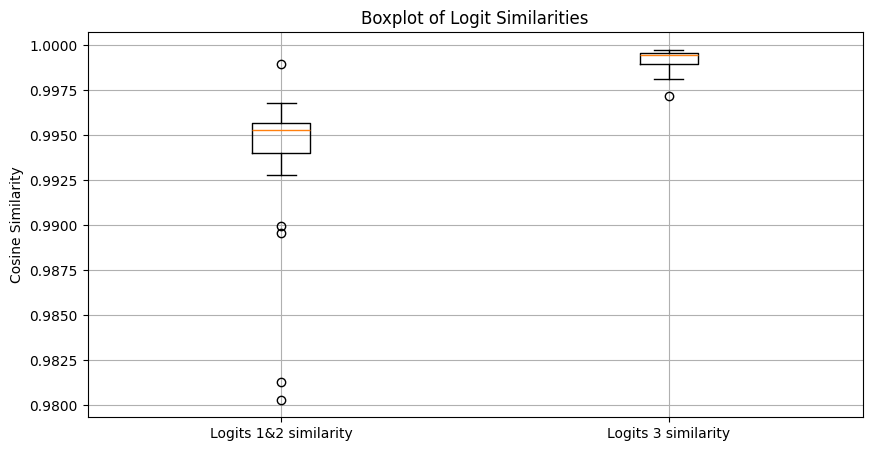

Average logits12 similarity: 0.994
Average logits3 similarity: 0.999


In [128]:
# Plot the boxplots
plt.figure(figsize=(10,5))
all_probs12 = [torch.softmax(out1.logits[0, -1], dim=0) @ torch.softmax(out2.logits[0, -1], dim=0) for out1, out2 in zip(out1, out2)]

plt.boxplot([all_logits12, all_logits3], labels=['Logits 1&2 similarity', 'Logits 3 similarity'])
plt.ylabel('Cosine Similarity')
plt.title('Boxplot of Logit Similarities')
plt.grid()
plt.show()

print(f"Average logits12 similarity: {torch.mean(torch.tensor(all_logits12)):.3f}")
print(f"Average logits3 similarity: {torch.mean(torch.tensor(all_logits3)):.3f}")


In [117]:
logits3

tensor([-72.8278, -73.2380, -75.7895,  ..., -87.6671, -85.4345, -76.9664])

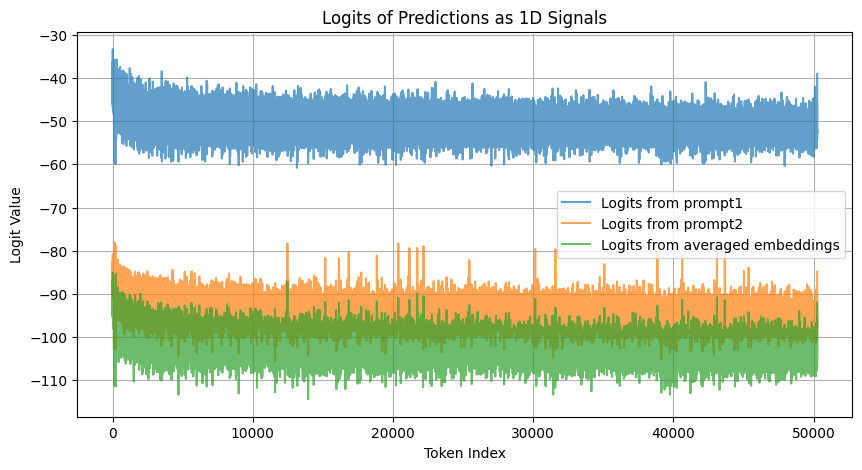

In [71]:
# Create a plot
plt.figure(figsize=(10, 5))
plt.plot(logits1, label='Logits from prompt1', alpha=0.7)
plt.plot(logits2, label='Logits from prompt2', alpha=0.7)
plt.plot(logits3, label='Logits from averaged embeddings', alpha=0.7)
plt.title('Logits of Predictions as 1D Signals')
plt.xlabel('Token Index')
plt.ylabel('Logit Value')
plt.legend()
plt.grid()
plt.show()
